In [5]:
%pip install tdqm
%pip install pandas-datareader
%pip install matplotlib
%pip install scikit-learn
%pip install xgboost
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


1. Fetching data from FRED...
   Data loaded: 432 months of history.

2. Running Granger Causality Test (Hypothesis Validation)...
   Checking if Fed Rates predict Inflation (p < 0.05):
   - Lag 1 is SIGNIFICANT (p=0.0227)
   - Lag 2 is SIGNIFICANT (p=0.0246)
   - Lag 3 is SIGNIFICANT (p=0.0055)
   - Lag 4 is SIGNIFICANT (p=0.0097)
   - Lag 5 is SIGNIFICANT (p=0.0016)
   - Lag 6 is SIGNIFICANT (p=0.0038)
   - Lag 7 is SIGNIFICANT (p=0.0096)
   - Lag 8 is SIGNIFICANT (p=0.0065)
   - Lag 9 is SIGNIFICANT (p=0.0113)
   - Lag 10 is SIGNIFICANT (p=0.0175)
   - Lag 11 is SIGNIFICANT (p=0.0242)

3. Generating Lag Features...

4. Starting Walk-Forward Validation (Expanding Window)...
   Forecasting 125 months step-by-step...


100%|██████████| 125/125 [00:39<00:00,  3.13it/s]



Final Results (Walk-Forward RMSE):
Linear Regression: 0.00265
XGBoost:           0.00238
Random Forest:     0.00257


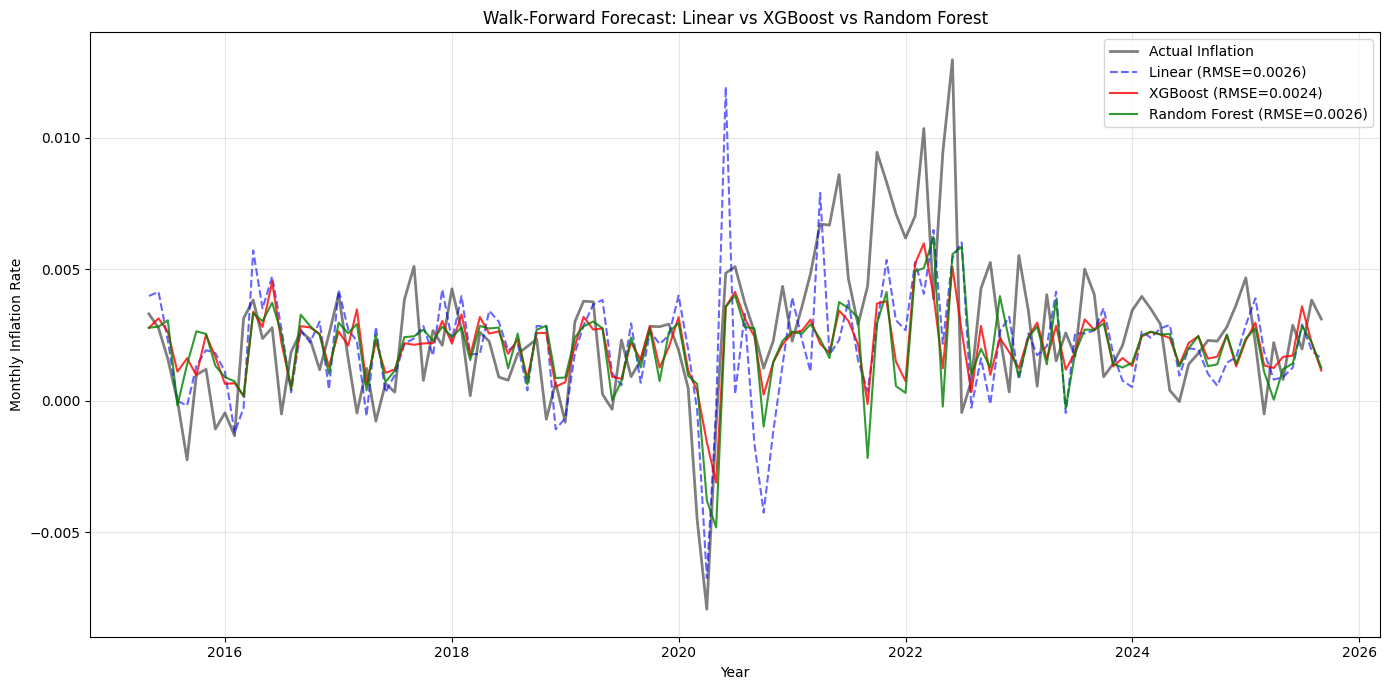

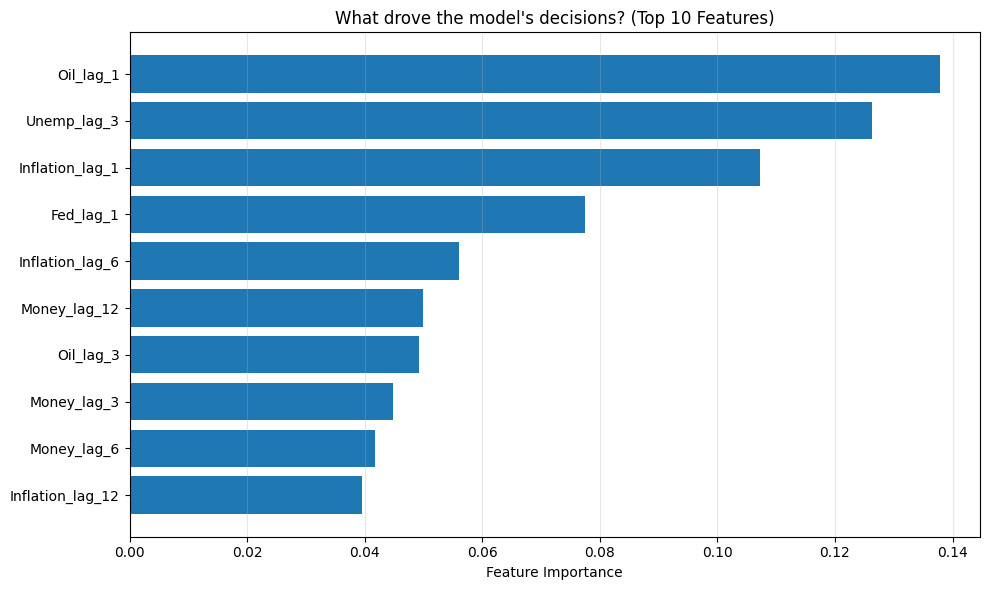

In [6]:
import pandas_datareader.data as web
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Optional: Progress bar for the loop 
try:
    from tqdm import tqdm
except ImportError:
    # simple fallback if tqdm isn't installed
    tqdm = lambda x: x 

# ==========================================
# 1. DATA INGESTION
# ==========================================
print("1. Fetching data from FRED...")

# We use a long history to give the model enough data to learn
start_date = datetime(1990, 1, 1) 
end_date = datetime.now()

# Tickers: 
# CPIAUCSL   = US CPI (Inflation)
# DCOILWTICO = Crude Oil Prices
# FEDFUNDS   = Federal Funds Interest Rate
# M2SL       = M2 Money Supply (Added for extra economic depth)
# UNRATE     = Unemployment Rate (Added for labor market context)
tickers = ['CPIAUCSL', 'DCOILWTICO', 'FEDFUNDS', 'M2SL', 'UNRATE']

try:
    raw_data = web.DataReader(tickers, 'fred', start_date, end_date)
except Exception as e:
    print(f"Error fetching data: {e}")
    exit()

# Resample to Monthly Start (MS)
df = raw_data.resample('MS').mean()
df.columns = ['US_CPI', 'Oil_Price', 'Fed_Rate', 'Money_Supply', 'Unemployment']

# Feature Engineering: Calculate Rates of Change
# We predict the % change (Inflation), not the raw index
df['Inflation_MoM'] = df['US_CPI'].pct_change()
df['Oil_Pct_Change'] = df['Oil_Price'].pct_change()
df['Money_Supply_Pct'] = df['Money_Supply'].pct_change()
# Fed Rate and Unemployment are already rates, but we diff them to make them stationary
df['Fed_Rate_Diff'] = df['Fed_Rate'].diff()
df['Unemployment_Diff'] = df['Unemployment'].diff()

print(f"   Data loaded: {len(df)} months of history.")

# ==========================================
# 2. STATISTICAL ANALYSIS (Granger Causality)
# ==========================================
print("\n2. Running Granger Causality Test (Hypothesis Validation)...")

# We test if the Fed Rate predicts Inflation
test_df = df[['Inflation_MoM', 'Fed_Rate_Diff']].dropna()
maxlag = 12

results = grangercausalitytests(test_df, maxlag=maxlag, verbose=False)

print(f"   Checking if Fed Rates predict Inflation (p < 0.05):")
found_sig = False
for lag in range(1, maxlag + 1):
    p_value = results[lag][0]['ssr_ftest'][1]
    if p_value < 0.05:
        print(f"   - Lag {lag} is SIGNIFICANT (p={p_value:.4f})")
        found_sig = True

if not found_sig:
    print("   - No significant lags found (Monetary policy lag might be > 12 months).")

# ==========================================
# 3. ADVANCED FEATURE ENGINEERING
# ==========================================
print("\n3. Generating Lag Features...")

# We create lags for ALL our economic indicators
lags = [1, 3, 6, 12] # Looking back 1 month, 1 quarter, half year, full year

for lag in lags:
    df[f'Inflation_lag_{lag}'] = df['Inflation_MoM'].shift(lag)
    df[f'Oil_lag_{lag}'] = df['Oil_Pct_Change'].shift(lag)
    df[f'Fed_lag_{lag}'] = df['Fed_Rate_Diff'].shift(lag)
    df[f'Money_lag_{lag}'] = df['Money_Supply_Pct'].shift(lag)
    df[f'Unemp_lag_{lag}'] = df['Unemployment_Diff'].shift(lag)

# Drop NaNs
df_ready = df.dropna()

# Define feature list
features = [col for col in df_ready.columns if 'lag' in col]
target = 'Inflation_MoM'


# ==========================================
# 4. WALK-FORWARD VALIDATION (With 3 Models)
# ==========================================
print("\n4. Starting Walk-Forward Validation (Expanding Window)...")

initial_train_size = int(len(df_ready) * 0.7)
test_size = len(df_ready) - initial_train_size

# Lists to store predictions
predictions_lr = []
predictions_xgb = []
predictions_rf = []  # <--- NEW
actuals = []

test_indices = df_ready.index[initial_train_size:]

print(f"   Forecasting {test_size} months step-by-step...")

for i in tqdm(range(test_size)):
    # 1. Define Expanding Window
    current_train_idx = initial_train_size + i
    
    X_train = df_ready[features].iloc[:current_train_idx]
    y_train = df_ready[target].iloc[:current_train_idx]
    
    X_test_point = df_ready[features].iloc[[current_train_idx]]
    y_test_point = df_ready[target].iloc[current_train_idx]
    
    # 2. Train Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    predictions_lr.append(lr.predict(X_test_point)[0])
    
    # 3. Train XGBoost
    xgb = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=3, random_state=42)
    xgb.fit(X_train, y_train)
    predictions_xgb.append(xgb.predict(X_test_point)[0])

    # 4. Train Random Forest (NEW)
    # n_estimators=100 means we average 100 different trees
    rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    predictions_rf.append(rf.predict(X_test_point)[0])
    
    actuals.append(y_test_point)

# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================

rmse_lr = np.sqrt(mean_squared_error(actuals, predictions_lr))
rmse_xgb = np.sqrt(mean_squared_error(actuals, predictions_xgb))
rmse_rf = np.sqrt(mean_squared_error(actuals, predictions_rf)) # <--- NEW

print(f"\nFinal Results (Walk-Forward RMSE):")
print(f"Linear Regression: {rmse_lr:.5f}")
print(f"XGBoost:           {rmse_xgb:.5f}")
print(f"Random Forest:     {rmse_rf:.5f}")

plt.figure(figsize=(14, 7))

# Plot Actuals
plt.plot(test_indices, actuals, label='Actual Inflation', color='black', alpha=0.5, linewidth=2)

# Plot Models
plt.plot(test_indices, predictions_lr, label=f'Linear (RMSE={rmse_lr:.4f})', linestyle='--', color='blue', alpha=0.6)
plt.plot(test_indices, predictions_xgb, label=f'XGBoost (RMSE={rmse_xgb:.4f})', linestyle='-', color='red', alpha=0.8)
# Plot Random Forest
plt.plot(test_indices, predictions_rf, label=f'Random Forest (RMSE={rmse_rf:.4f})', linestyle='-', color='green', alpha=0.8)

plt.title('Walk-Forward Forecast: Linear vs XGBoost vs Random Forest')
plt.xlabel('Year')
plt.ylabel('Monthly Inflation Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# ==========================================
# 6. FEATURE IMPORTANCE (From the final model)
# ==========================================
plt.figure(figsize=(10, 6))
importances = xgb.feature_importances_
sorted_idx = np.argsort(importances)[-10:] # Top 10

plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("What drove the model's decisions? (Top 10 Features)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()